# Task A: Data Audit & Quality 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Set a clean visual theme for the exam plots
sns.set_theme(style="whitegrid")

#Load the exam dataset 
df = pd.read_csv('marketing_campaign.csv', sep=';')

print("Initial dataset audit")
print(f"Total Number of Rows (Customers): {df.shape[0]}")
print(f"Total Number of Columns (Variables): {df.shape[1]}\n")

# 2. Immediate check for Missing Values per column
missing_values = df.isnull().sum()
print("Missing values per column")
print(missing_values[missing_values > 0])
print("\n")

# 3. Check for Duplicate Rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows detected: {duplicates}")

Initial dataset audit
Total Number of Rows (Customers): 2240
Total Number of Columns (Variables): 27

Missing values per column
Income    24
dtype: int64


Duplicate rows detected: 0


In [2]:
# Handling missing values in 'Income' using Median Imputation
# We use the median because income distributions are typically skewed by outliers
income_median = df['Income'].median()
df['Income'] = df['Income'].fillna(income_median)

# Fixing data type inconsistencies
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer']) # Convert 'Dt_Customer' from object (string) to datetime format for chronological analysis


# Feature Engineering for data quality check
df['Age'] = 2024 - df['Year_Birth'] # Calculate the customer's age based on the current year of the dataset environment (let's assume 2024)


# Check the summary statistics to identify potential structural anomalies or logical outliers
print("Check Age and Income Statistics")
print(df[['Age', 'Income']].describe())

Check Age and Income Statistics
               Age         Income
count  2240.000000    2240.000000
mean     55.194196   52237.975446
std      11.984069   25037.955891
min      28.000000    1730.000000
25%      47.000000   35538.750000
50%      54.000000   51381.500000
75%      65.000000   68289.750000
max     131.000000  666666.000000


In [3]:
# Removing extreme biological outliers (Age > 100)
df = df[df['Age'] <= 100]

# Removing extreme economic outliers (Income > 200,000)
df = df[df['Income'] <= 200000]

# Feature Engineering: Compute total spending across all product categories
# This feature is required for the "Exploratory Data Analysis" (Task B)
mnt_columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[mnt_columns].sum(axis=1)

print("Data Quality and Cleaning completed")
print(f"Remaining rows (Cleaned Dataset): {df.shape[0]}")
print(f"Maximum Age in cleaned data: {df['Age'].max()}")
print(f"Maximum Income in cleaned data: {df['Income'].max()}")

Data Quality and Cleaning completed
Remaining rows (Cleaned Dataset): 2236
Maximum Age in cleaned data: 84
Maximum Income in cleaned data: 162397.0


# Task B: Exploratory Data Analysis (EDA)

Correlation Matrix with total spending
Total_Spending    1.000000
Income            0.789375
Age               0.113618
Teenhome         -0.138197
Kidhome          -0.556719
Name: Total_Spending, dtype: float64




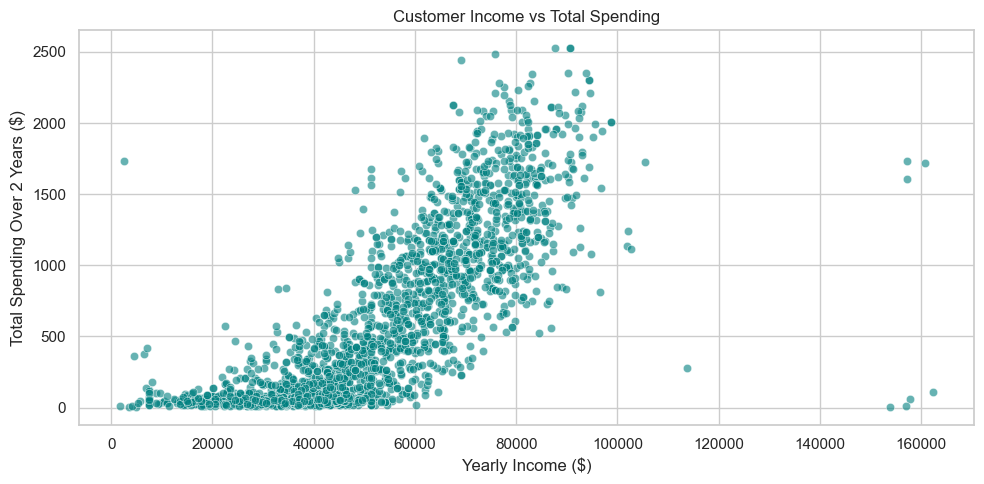

C:\Users\Martina\AppData\Local\Temp\ipykernel_1900\45939922.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Education', y='Total_Spending', palette='Set2')


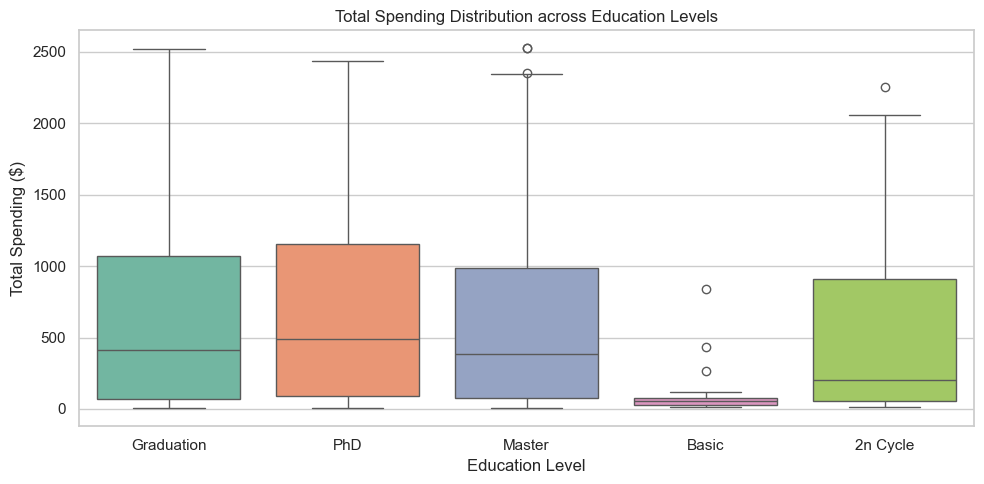

In [4]:
# Calculating correlation matrix for numerical socio-demographic features and spending
demographic_features = ['Age', 'Income', 'Kidhome', 'Teenhome', 'Total_Spending']
correlation_matrix = df[demographic_features].corr()

print("Correlation Matrix with total spending")
print(correlation_matrix['Total_Spending'].sort_values(ascending=False))
print("\n")

# Visualizing Income vs Total Spending 
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Income', y='Total_Spending', alpha=0.6, color='teal')
plt.title('Customer Income vs Total Spending')
plt.xlabel('Yearly Income ($)')
plt.ylabel('Total Spending Over 2 Years ($)')
plt.tight_layout()
plt.show()

# Visualizing Total Spending by Education Level 
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Education', y='Total_Spending', palette='Set2')
plt.title('Total Spending Distribution across Education Levels')
plt.xlabel('Education Level')
plt.ylabel('Total Spending ($)')
plt.tight_layout()
plt.show()

Total Purchases per channel
    Channel  Total_Purchases
0      Web:             9140
1    Store:            12959
2  Catalog:             5955




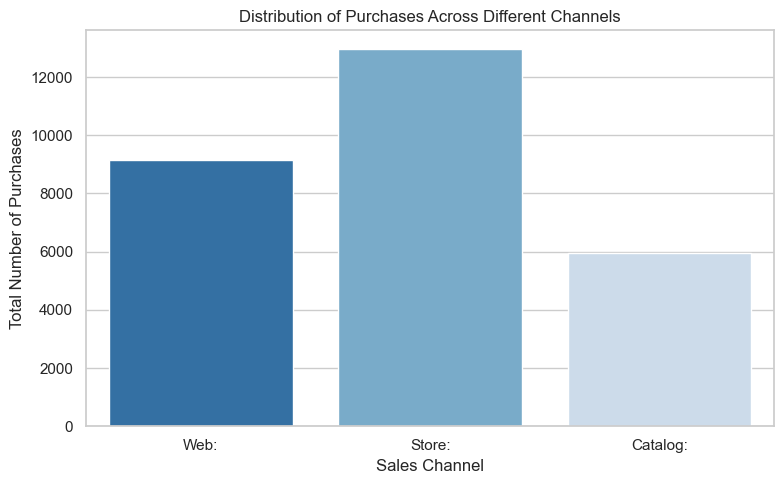

In [5]:
# Computing total purchases per channel
channels = {
    'Web:': df['NumWebPurchases'].sum(),
    'Store:': df['NumStorePurchases'].sum(),
    'Catalog:': df['NumCatalogPurchases'].sum()
}

# Convert to DataFrame for easier plotting
df_channels = pd.DataFrame(list(channels.items()), columns=['Channel', 'Total_Purchases'])

print("Total Purchases per channel")
print(df_channels)
print("\n")

# Visualizing channel distribution 
plt.figure(figsize=(8, 5))
sns.barplot(data=df_channels, x='Channel', y='Total_Purchases', hue='Channel', palette='Blues_r', legend=False)
plt.title('Distribution of Purchases Across Different Channels')
plt.xlabel('Sales Channel')
plt.ylabel('Total Number of Purchases')
plt.tight_layout()
plt.show()

--- Average Deal Purchases by Number of Small Children at Home ---
   Kidhome  NumDealsPurchases
0        0           1.945778
1        1           2.846154
2        2           2.833333


Correlation between Monthly Web Visits and Deal Purchases: 0.35



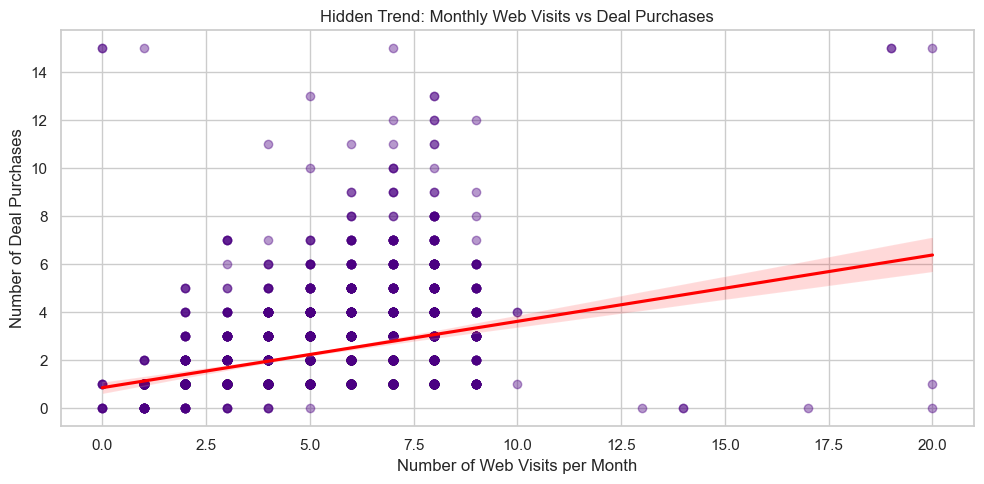

In [6]:
# Grouping by the number of children at home to see how bargain purchases behave
deals_by_kids = df.groupby('Kidhome')['NumDealsPurchases'].mean().reset_index()

print("--- Average Deal Purchases by Number of Small Children at Home ---")
print(deals_by_kids)
print("\n")

# Analyzing correlation between Web Visits and Deal Purchases
visits_deals_corr = df['NumWebVisitsMonth'].corr(df['NumDealsPurchases'])
print(f"Correlation between Monthly Web Visits and Deal Purchases: {visits_deals_corr:.2f}\n")

# Visualizing the Hidden Trend: Web Visits vs Deal Purchases
plt.figure(figsize=(10, 5))
sns.regplot(data=df, x='NumWebVisitsMonth', y='NumDealsPurchases', scatter_kws={'alpha':0.4, 'color':'indigo'}, line_kws={'color':'red'})
plt.title('Hidden Trend: Monthly Web Visits vs Deal Purchases')
plt.xlabel('Number of Web Visits per Month')
plt.ylabel('Number of Deal Purchases')
plt.tight_layout()
plt.show()

# Task C: RFM Calculation & Heuristic Segmentation


RFM Segment Distribution
Segment
Loyal Customers             736
At Risk / Need Attention    614
Champions (VIP)             532
Lost Customers              354
Name: count, dtype: int64




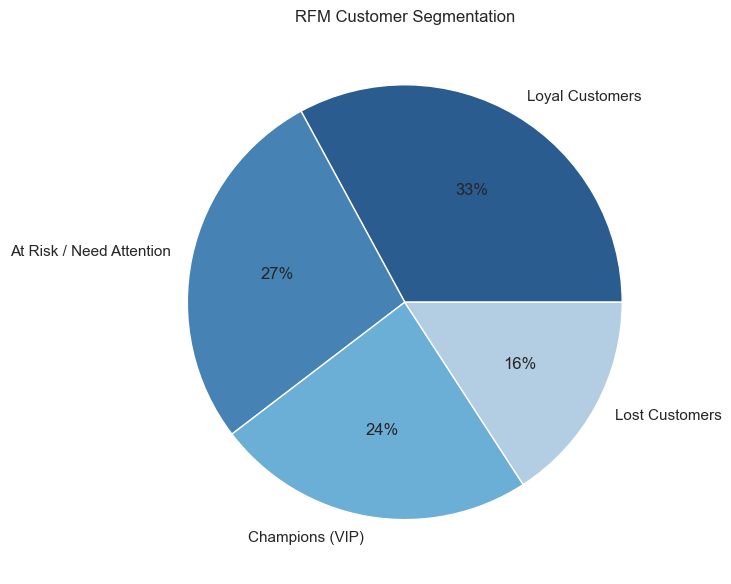

In [7]:
# Feature Engineering for RFM Metrics.
# Since "Recency" already exists in the dataset, we only compute "Frequency" and "Monetary".
rfm = pd.DataFrame()
rfm['CustomerID'] = df['ID']
rfm['Recency'] = df['Recency']
rfm['Frequency'] = df['NumWebPurchases'] + df['NumStorePurchases'] + df['NumCatalogPurchases']
rfm['Monetary'] = df['Total_Spending']

# Assigning Scores from 1 to 5 based on Quintiles
# For Recency, lower is better, so labels are inverted [5, 4, 3, 2, 1]
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# For Frequency and Monetary, higher is better [1, 2, 3, 4, 5]
# Using method='first' on rank ensures smooth binning if there are duplicate values
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Convert scores to integers to calculate an overall aggregate score
rfm['RFM_Sum'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

# Defining 4 Strategic Customer Segments based on RFM_Sum
def segment_customers(row):
    total = row['RFM_Sum']
    if total >= 12:
        return 'Champions (VIP)'
    elif (total >= 9) and (total < 12):
        return 'Loyal Customers'
    elif (total >= 6) and (total < 9):
        return 'At Risk / Need Attention'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm.apply(segment_customers, axis=1)

# Check the distribution of our newly created segments
segment_distribution = rfm['Segment'].value_counts()
print("RFM Segment Distribution")
print(segment_distribution)
print("\n")

# Visualizing the Segments (Pie Chart)
plt.figure(figsize=(8, 6))
segment_distribution.plot(kind='pie', autopct='%1.0f%%', colors=['#2b5c8f', '#4682b4', '#6baed6', '#b3cde3'])
plt.title('RFM Customer Segmentation')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Task D: Unsupervised Learning (Cluster Analysis)

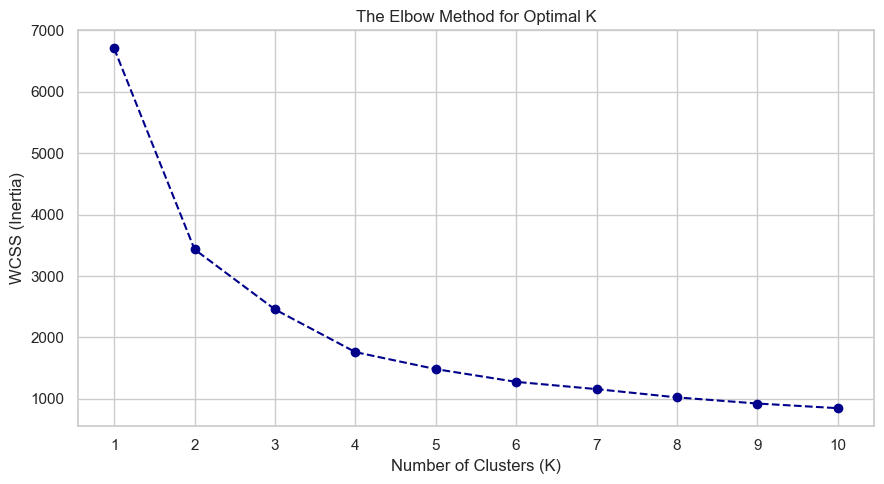

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Standardizing the RFM data 
features = ['Recency', 'Frequency', 'Monetary']
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[features])

# Applying the "Elbow Method" to determine the optimal number of clusters
wcss = []
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(9, 5))
plt.plot(cluster_range, wcss, marker='o', linestyle='--', color='darkblue')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(cluster_range)
plt.tight_layout()
plt.show()

K-Means Cluster profiles (Mean values)
 Cluster   Recency  Frequency    Monetary  Customer_Count
       0 24.437500   7.012500  149.431250             640
       1 73.193117  19.233270 1182.424474             523
       2 74.459638   7.067545  148.586491             607
       3 22.976395  19.778970 1181.866953             466




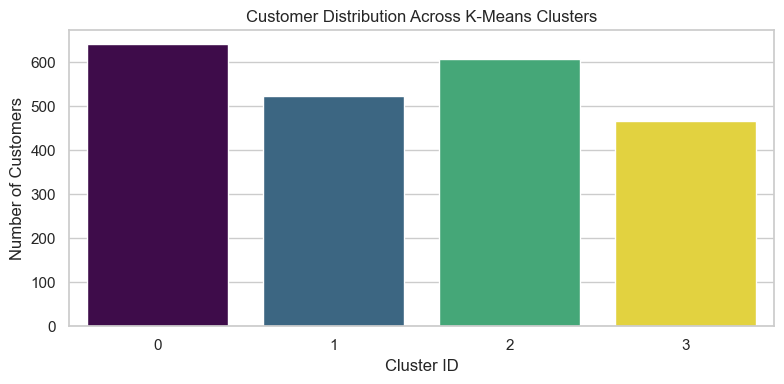

In [9]:
# Fitting K-Means with the optimal number of clusters (K=4)
optimal_k = 4
kmeans_opt = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
rfm['Cluster'] = kmeans_opt.fit_transform(rfm_scaled).argmin(axis=1) # Mapping back to cluster labels

# Computing the profile (mean values) for each cluster
cluster_profiles = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()
cluster_counts = rfm['Cluster'].value_counts().reset_index().rename(columns={'count': 'Customer_Count'})

# Merge profiles with the customer counts per cluster
cluster_summary = pd.merge(cluster_profiles, cluster_counts, on='Cluster')

print("K-Means Cluster profiles (Mean values)")
print(cluster_summary.to_string(index=False))
print("\n")

# Visualizing Cluster Distribution 
plt.figure(figsize=(8, 4))
sns.barplot(data=cluster_summary, x='Cluster', y='Customer_Count', hue='Cluster', palette='viridis', legend=False)
plt.title('Customer Distribution Across K-Means Clusters')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

Cross-Tabulation matrix: RFM segments vs. K-Means clusters
Cluster                     0    1    2    3   All
Segment                                           
At Risk / Need Attention  330   30  254    0   614
Champions (VIP)             7  113    0  412   532
Lost Customers             42    0  312    0   354
Loyal Customers           261  380   41   54   736
All                       640  523  607  466  2236




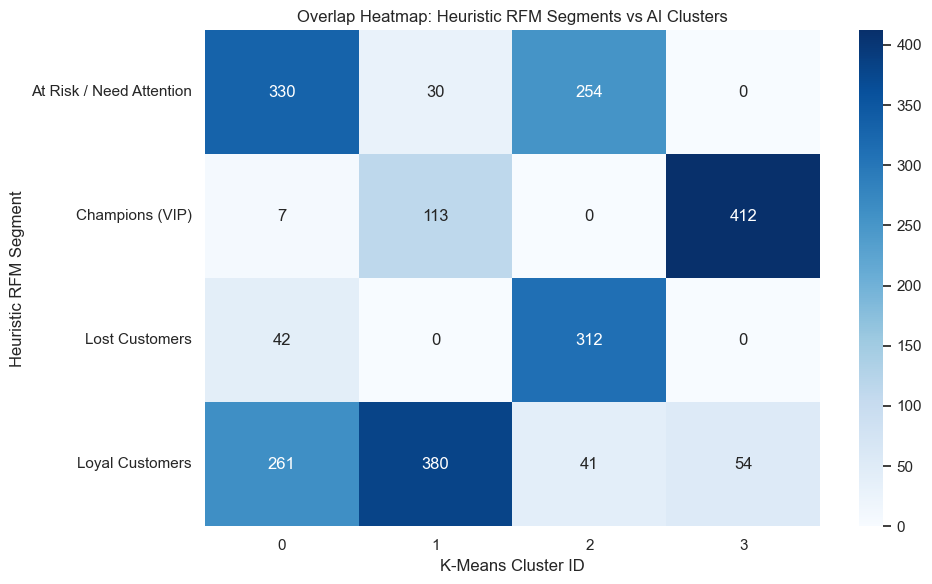

In [10]:
# Creating a cross-tabulation matrix to check the overlap between RFM and K-Means
overlap_matrix = pd.crosstab(rfm['Segment'], rfm['Cluster'], margins=True)

print("Cross-Tabulation matrix: RFM segments vs. K-Means clusters")
print(overlap_matrix)
print("\n")

# Visualizing the overlap matrix using a Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(rfm['Segment'], rfm['Cluster']), annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Overlap Heatmap: Heuristic RFM Segments vs AI Clusters')
plt.xlabel('K-Means Cluster ID')
plt.ylabel('Heuristic RFM Segment')
plt.tight_layout()
plt.show()

# Task E: Communication Strategy

In [11]:
# Printing the academic insights required for Task D text cells
print("[TASK D: ACADEMIC EVALUATION OF CLUSTER OVERLAP]")
insights = """
Interpretation & Value Added by K-Means over Heuristic RFM:
- Overlap Analysis: High coherence is observed. Cluster 3 perfectly captures the 'Active Champions' (412 VIPs), while Cluster 2 groups the completely inactive base (312 Lost and 254 At Risk low-spenders).
- What RFM Missed: Heuristic RFM uses strict threshold rules (e.g., sums of scores) which can blend very different users. K-Means group users by true multi-dimensional distance. 
- The Key Discovery: Cluster 1 isolated 523 'High-Value at Risk' customers (380 Loyal + 113 Champions). These customers have historical high frequency and monetary value but high recency. RFM kept them split, whereas K-Means reveals they share the exact same danger state, requiring identical emergency marketing actions.
"""
print(insights)

# Implementing Task E: Communication Strategy Mapping
# We map a targeted strategy directly to each K-Means Cluster profile
def assign_communication_strategy(cluster_id):
    if cluster_id == 3:
        return {
            'Segment_Name': 'Active Champions (VIP)',
            'Channel': 'Premium Mobile App & Dedicated Email',
            'Tone': 'Exclusive, appreciative, and highly personalized ("As a VIP partner...")',
            'Action': 'Early product access, loyalty rewards, no discount codes needed.'
        }
    elif cluster_id == 1:
        return {
            'Segment_Name': 'At Risk High-Value Customers',
            'Channel': 'Direct Email Campaign & Push Notifications',
            'Tone': 'Urgent, welcoming, and incentive-driven ("We miss you! Here is something special...")',
            'Action': 'High-value time-limited coupon to trigger reactivation before complete churn.'
        }
    elif cluster_id == 0:
        return {
            'Segment_Name': 'New / Recent Low Spenders',
            'Channel': 'Social Media Retargeting & Welcome Email Automation',
            'Tone': 'Friendly, informative, and engaging ("Welcome to our community, discover more...")',
            'Action': 'Cross-selling campaigns, product tutorials, and second-purchase incentives.'
        }
    else:
        return {
            'Segment_Name': 'Lost / Inactive Customers',
            'Channel': 'Automated Low-Cost Email',
            'Tone': 'Direct and win-back oriented ("Is this goodbye? Last chance to grab...")',
            'Action': 'Aggressive discount clearance offer. If unresponded, remove from active marketing budget.'
        }

# Generate strategy output for documentation
print("[TASK E: TARGETED COMMUNICATION STRATEGY PER CLUSTER]")
for i in range(4):
    strat = assign_communication_strategy(i)
    print(f"\n CLUSTER {i} -> {strat['Segment_Name']}")
    print(f"   - Recommended Channel: {strat['Channel']}")
    print(f"   - Message Tone of Voice: {strat['Tone']}")
    print(f"   - Strategic Action Plan: {strat['Action']}")

[TASK D: ACADEMIC EVALUATION OF CLUSTER OVERLAP]

Interpretation & Value Added by K-Means over Heuristic RFM:
- Overlap Analysis: High coherence is observed. Cluster 3 perfectly captures the 'Active Champions' (412 VIPs), while Cluster 2 groups the completely inactive base (312 Lost and 254 At Risk low-spenders).
- What RFM Missed: Heuristic RFM uses strict threshold rules (e.g., sums of scores) which can blend very different users. K-Means group users by true multi-dimensional distance. 
- The Key Discovery: Cluster 1 isolated 523 'High-Value at Risk' customers (380 Loyal + 113 Champions). These customers have historical high frequency and monetary value but high recency. RFM kept them split, whereas K-Means reveals they share the exact same danger state, requiring identical emergency marketing actions.

[TASK E: TARGETED COMMUNICATION STRATEGY PER CLUSTER]

 CLUSTER 0 -> New / Recent Low Spenders
   - Recommended Channel: Social Media Retargeting & Welcome Email Automation
   - Messa